# Análisis exploratorio de los datos
Este notebook se encarga de analizar los datos. Desde la creación de dataframes con información de cromosomas e imagenes, hasta la obtención de información de los datos.

## 1. Organización y creación de dataframes
Organizamos los datos para generar un dataframe con la información de los cromosomas de las imagenes y un dataframe con la información de las imagenes.

In [ ]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path
# ==========================================================
# CONFIGURACIÓN
# ==========================================================
# Carpeta donde están los archivos XML
data_path = Path('../../data/raw')
ANNOTATIONS_DIR = data_path / 'annotations'

# Carpeta donde se guardarán los CSV
OUTPUT_DIR = Path.cwd()

# ==========================================================
# LISTAS PARA ALMACENAR LOS REGISTROS
# ==========================================================
images_data = []
chromosomes_data = []

# ID incremental global para cada cromosoma
chromosome_id = 1

# ==========================================================
# RECORRER TODOS LOS ARCHIVOS XML
# ==========================================================
for file in os.listdir(ANNOTATIONS_DIR):
    
    # Procesar únicamente archivos .xml
    if not file.lower().endswith(".xml"):
        continue

    xml_path = os.path.join(ANNOTATIONS_DIR, file)

    # Parsear XML
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # ------------------------------------------------------
    # EXTRAER INFORMACIÓN DE LA IMAGEN
    # ------------------------------------------------------
    # Nombre de archivo de imagen (ej. 103064.jpg)
    file_name = root.find("filename").text

    # ID de imagen = nombre del archivo sin extensión
    id_image = os.path.splitext(file_name)[0]

    # Tamaño de la imagen
    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    # Agregar registro al dataframe images
    images_data.append({
        "id_image": id_image,
        "file_name": file_name,
        "width": width,
        "height": height
    })

    # ------------------------------------------------------
    # EXTRAER INFORMACIÓN DE LOS CROMOSOMAS
    # ------------------------------------------------------
    for obj in root.findall("object"):
        label = obj.find("name").text

        bndbox = obj.find("bndbox")
        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)

        chromosomes_data.append({
            "id_chromosome": chromosome_id,
            "id_image": id_image,
            "etiqueta": label,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax
        })

        chromosome_id += 1

# ==========================================================
# CREAR DATAFRAMES
# ==========================================================
df_images = pd.DataFrame(images_data)
df_chromosomes = pd.DataFrame(chromosomes_data)

# ==========================================================
# GUARDAR CSV
# ==========================================================
images_csv = os.path.join(OUTPUT_DIR, "images.csv")
chromosomes_csv = os.path.join(OUTPUT_DIR, "chromosomes.csv")
print("Proceso completado exitosamente.")
print(f"Imágenes procesadas: {len(df_images)}")
print(f"Cromosomas extraídos: {len(df_chromosomes)}")

..\..\data\raw\annotations c:\Users\Acer\Desktop\API\sibun_ag\Chromosome-identifier-TDSP\scripts\data_analytics


Con esto ya hemos generado los archivos csv "images" y "chromosomes", que contienen la información de los datos de manera más organizada y limpia. Finalmente cargamos los csv como dataframes para realizar su análisis.

In [ ]:
df_images = pd.read_csv('images.csv')
df_chromosomes = pd.read_csv('chromosomes.csv')


=== DataFrame Images ===
  id_image   file_name  width  height
0   103064  103064.jpg    524     581
1   103071  103071.jpg    644     709
2   103072  103072.jpg    637     590
3   103081  103081.jpg    658     586
4   103082  103082.jpg   1134     759

=== DataFrame Chromosomes ===
   id_chromosome id_image etiqueta  xmin  ymin  xmax  ymax
0              1   103064       A1   237   274   303   393
1              2   103064       A1    91   205   200   302
2              3   103064       A2   378   214   464   281
3              4   103064       A2   144   313   205   419
4              5   103064       A3   169   248   243   322


## 2. Análisis de los dataframes
Utilizando los dataframes generados realizamos un análisis en busqueda de nulos, tipos, max,mins y otras caracteristicas.

In [7]:
pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Acer\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


INFORMACIÓN GENERAL

--- df_images ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_image   5000 non-null   object
 1   file_name  5000 non-null   object
 2   width      5000 non-null   int64 
 3   height     5000 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 156.4+ KB
None

--- df_chromosomes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229852 entries, 0 to 229851
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id_chromosome  229852 non-null  int64 
 1   id_image       229852 non-null  object
 2   etiqueta       229852 non-null  object
 3   xmin           229852 non-null  int64 
 4   ymin           229852 non-null  int64 
 5   xmax           229852 non-null  int64 
 6   ymax           229852 non-null  int64 
 7   bbox_width     229852 non-nu

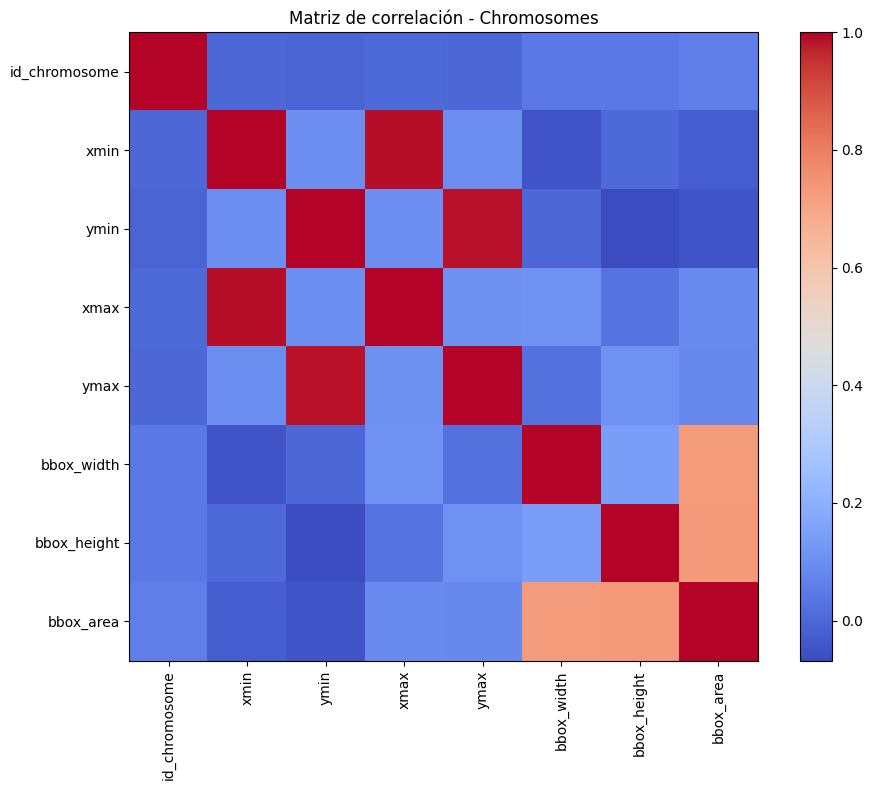

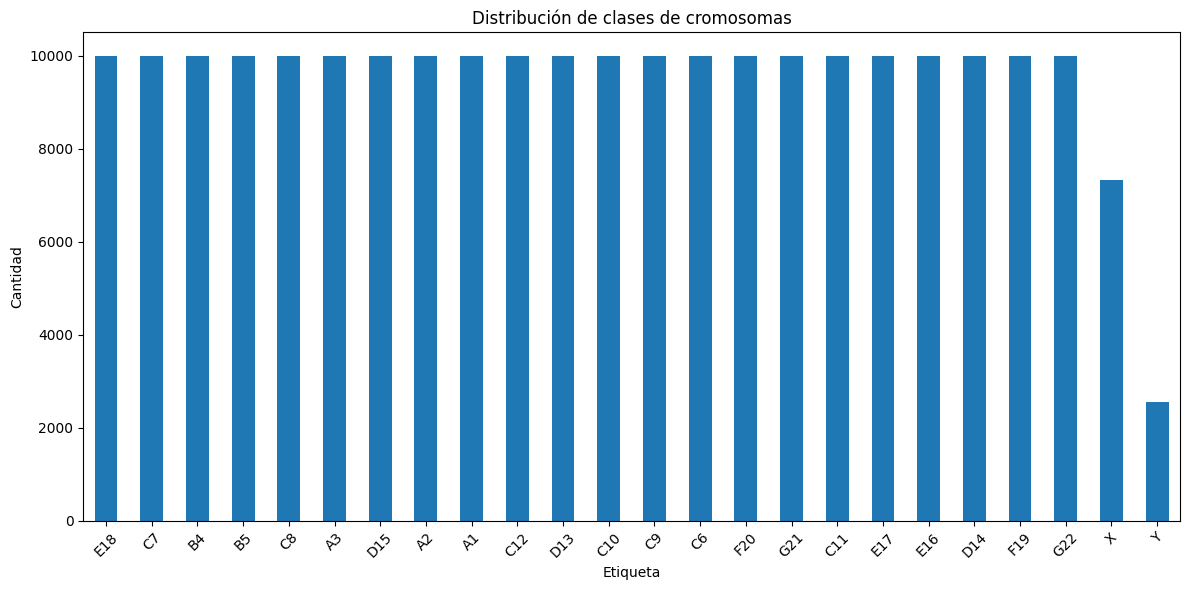


ESTADÍSTICAS BOUNDING BOX
          bbox_width    bbox_height      bbox_area
count  229852.000000  229852.000000  229852.000000
mean       71.621169      71.179833    5237.682474
std        31.178588      31.194482    3594.965040
min        16.000000      17.000000     440.000000
25%        47.000000      47.000000    2597.000000
50%        65.000000      65.000000    4288.000000
75%        90.000000      89.000000    6784.000000
max       317.000000     268.000000   43884.000000


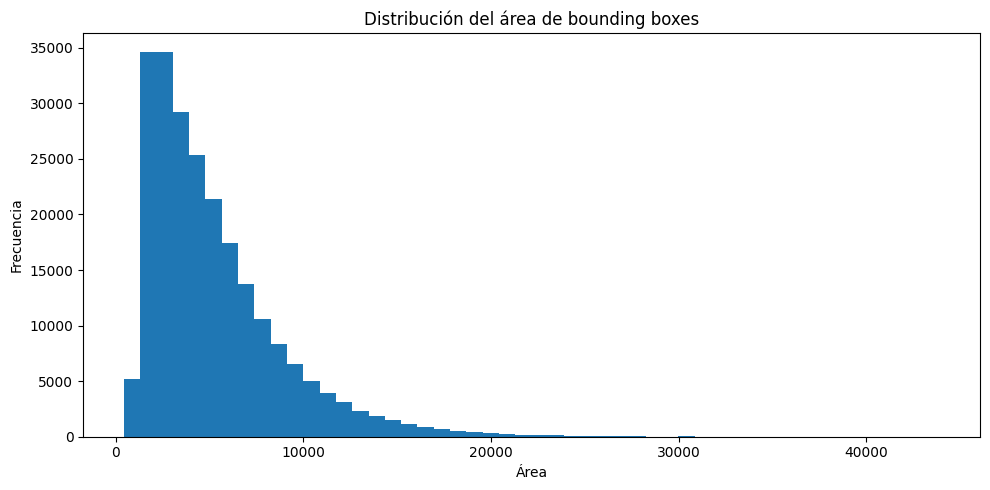


CROMOSOMAS POR IMAGEN
count    5000.000000
mean       45.970400
std         0.311036
min        43.000000
25%        46.000000
50%        46.000000
75%        46.000000
max        50.000000
dtype: float64


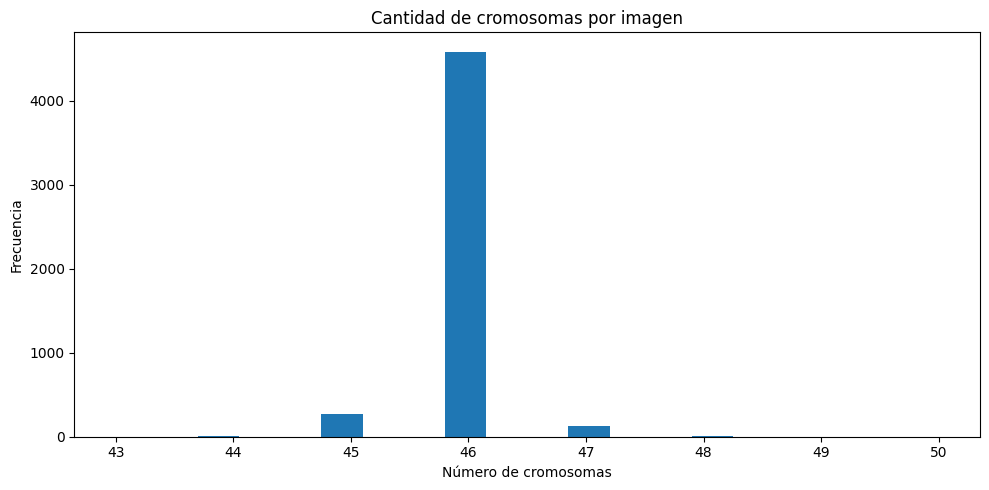


VALIDACIÓN DE COORDENADAS
Bounding boxes inválidos: 0


In [ ]:
# ==========================================================
# ANÁLISIS EXPLORATORIO (EDA)
# DataFrames:
#   - df_images
#   - df_chromosomes
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. INFORMACIÓN GENERAL
# ==========================================================

print("=" * 60)
print("INFORMACIÓN GENERAL")
print("=" * 60)

print("\n--- df_images ---")
print(df_images.info())

print("\n--- df_chromosomes ---")
print(df_chromosomes.info())

print("\n" + "=" * 60)
print("RESUMEN ")
print("=" * 60)

print(f"Total imágenes: {len(df_images)}")
print(f"Total cromosomas: {len(df_chromosomes)}")
print(f"Clases únicas: {df_chromosomes['etiqueta'].nunique()}")

print("\nEtiquetas únicas:")
print(sorted(df_chromosomes["etiqueta"].unique()))
# ==========================================================
# 2. PRIMERAS FILAS
# ==========================================================

print("\n" + "=" * 60)
print("PRIMERAS FILAS")
print("=" * 60)

print("\n--- df_images ---")
print(df_images.head())

print("\n--- df_chromosomes ---")
print(df_chromosomes.head())

# ==========================================================
# 3. VALORES NULOS
# ==========================================================

print("\n" + "=" * 60)
print("VALORES NULOS")
print("=" * 60)

print("\n--- df_images ---")
print(df_images.isnull().sum())

print("\n--- df_chromosomes ---")
print(df_chromosomes.isnull().sum())

# ==========================================================
# 4. DUPLICADOS
# ==========================================================

print("\n" + "=" * 60)
print("DUPLICADOS")
print("=" * 60)

print("\nDuplicados en df_images:")
print(df_images.duplicated().sum())

print("\nDuplicados en df_chromosomes:")
print(df_chromosomes.duplicated().sum())

# ==========================================================
# 5. ESTADÍSTICAS DESCRIPTIVAS
# ==========================================================

print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)

print("\n--- df_images ---")
print(df_images.describe())

print("\n--- df_chromosomes ---")
print(df_chromosomes.describe())

# ==========================================================
# 6. VALORES MÍNIMOS Y MÁXIMOS
# ==========================================================

print("\n" + "=" * 60)
print("VALORES MÍNIMOS Y MÁXIMOS")
print("=" * 60)

columnas_numericas_images = df_images.select_dtypes(include='number').columns
columnas_numericas_chrom = df_chromosomes.select_dtypes(include='number').columns

print("\n--- df_images ---")
for col in columnas_numericas_images:
    print(f"{col}: min={df_images[col].min()} | max={df_images[col].max()}")

print("\n--- df_chromosomes ---")
for col in columnas_numericas_chrom:
    print(f"{col}: min={df_chromosomes[col].min()} | max={df_chromosomes[col].max()}")

# ==========================================================
# 7. DISTRIBUCIÓN DE CLASES (ETIQUETAS)
# ==========================================================

print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE CLASES")
print("=" * 60)

conteo_etiquetas = df_chromosomes["etiqueta"].value_counts()

print(conteo_etiquetas)

# ==========================================================
# 8. CORRELACIONES
# ==========================================================

print("\n" + "=" * 60)
print("MATRIZ DE CORRELACIÓN")
print("=" * 60)

correlation = df_chromosomes.select_dtypes(include='number').corr()

print(correlation)

# ==========================================================
# 9. VISUALIZACIÓN DE CORRELACIÓN
# ==========================================================

plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=90)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Matriz de correlación - Chromosomes")

plt.tight_layout()
plt.show()

# ==========================================================
# 10. HISTOGRAMA DE ETIQUETAS
# ==========================================================

plt.figure(figsize=(12, 6))

conteo_etiquetas.plot(kind='bar')

plt.title("Distribución de clases de cromosomas")
plt.xlabel("Etiqueta")
plt.ylabel("Cantidad")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==========================================================
# 11. TAMAÑO DE BOUNDING BOXES
# ==========================================================

# Ancho y alto del bounding box
df_chromosomes["bbox_width"] = (
    df_chromosomes["xmax"] - df_chromosomes["xmin"]
)

df_chromosomes["bbox_height"] = (
    df_chromosomes["ymax"] - df_chromosomes["ymin"]
)

# Área
df_chromosomes["bbox_area"] = (
    df_chromosomes["bbox_width"] *
    df_chromosomes["bbox_height"]
)

print("\n" + "=" * 60)
print("ESTADÍSTICAS BOUNDING BOX")
print("=" * 60)

print(df_chromosomes[
    ["bbox_width", "bbox_height", "bbox_area"]
].describe())

# ==========================================================
# 12. HISTOGRAMA ÁREAS
# ==========================================================

plt.figure(figsize=(10, 5))

plt.hist(df_chromosomes["bbox_area"], bins=50)

plt.title("Distribución del área de bounding boxes")
plt.xlabel("Área")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# ==========================================================
# 13. CANTIDAD DE CROMOSOMAS POR IMAGEN
# ==========================================================

chromosomes_per_image = (
    df_chromosomes.groupby("id_image")
    .size()
)

print("\n" + "=" * 60)
print("CROMOSOMAS POR IMAGEN")
print("=" * 60)

print(chromosomes_per_image.describe())

plt.figure(figsize=(10, 5))

plt.hist(chromosomes_per_image, bins=20)

plt.title("Cantidad de cromosomas por imagen")
plt.xlabel("Número de cromosomas")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()